In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('flight_pricing_dataset.csv')
df_clean = df.copy()
df_clean = df_clean.drop_duplicates()
print(df_clean.dtypes)
#all the datatypes are string


Flight_ID                str
Airline                  str
Source                   str
Destination              str
Departure_Date           str
Departure_Time           str
Arrival_Time             str
Duration                 str
Total_Stops              str
Distance_km              str
Travel_Class             str
Days_Before_Departure    str
Season                   str
Weekday                  str
Aircraft_Type            str
Booking_Channel          str
Passenger_Count          str
Price                    str
dtype: object


In [3]:
# many values of distance have km attached to it. we have to clean it.
df_clean['Distance_km'] = df_clean['Distance_km'].astype(str).str.replace(' km', '', regex = False)
df_clean['Distance_km'] = pd.to_numeric(df_clean['Distance_km'], errors='coerce')


In [4]:
#some values of price has Rs. attached to it. we have to strip that and convert it to numeric 
df_clean['Price'] = df_clean['Price'].astype(str).str.replace('Rs. ','',regex = False)
df_clean['Price'] = pd.to_numeric(df_clean['Price'],errors='coerce')

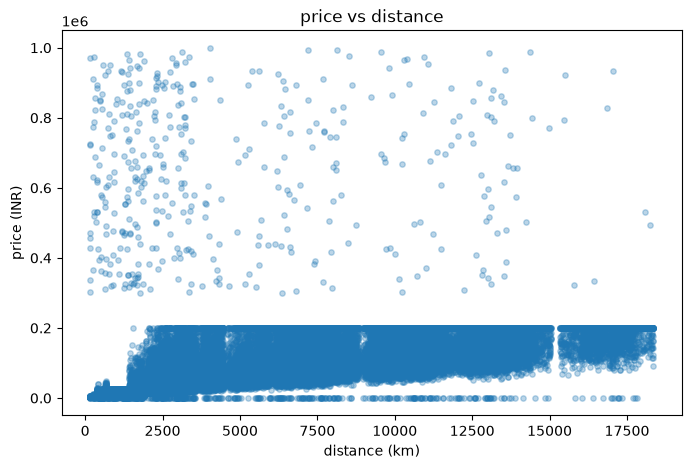

In [5]:
# plotting a scatter plot of price vs distance
plt.figure(figsize=(8,5))
distprice = df_clean.dropna(subset=['Distance_km','Price'])
plt.scatter(distprice['Distance_km'],distprice['Price'],alpha=0.3,s=15)
plt.title('price vs distance')
plt.xlabel('distance (km)')
plt.ylabel('price (INR)')
plt.show()
 

1) massive price branding from 0 to 2 lakh
2) the dots higher up could be representing extreme luxury flights, private charters or corrupted/error records
3) price starts from 0 and has an upward slope until around 2000km. after that price ceiling is constant at 2 lakh regardless of extra distance

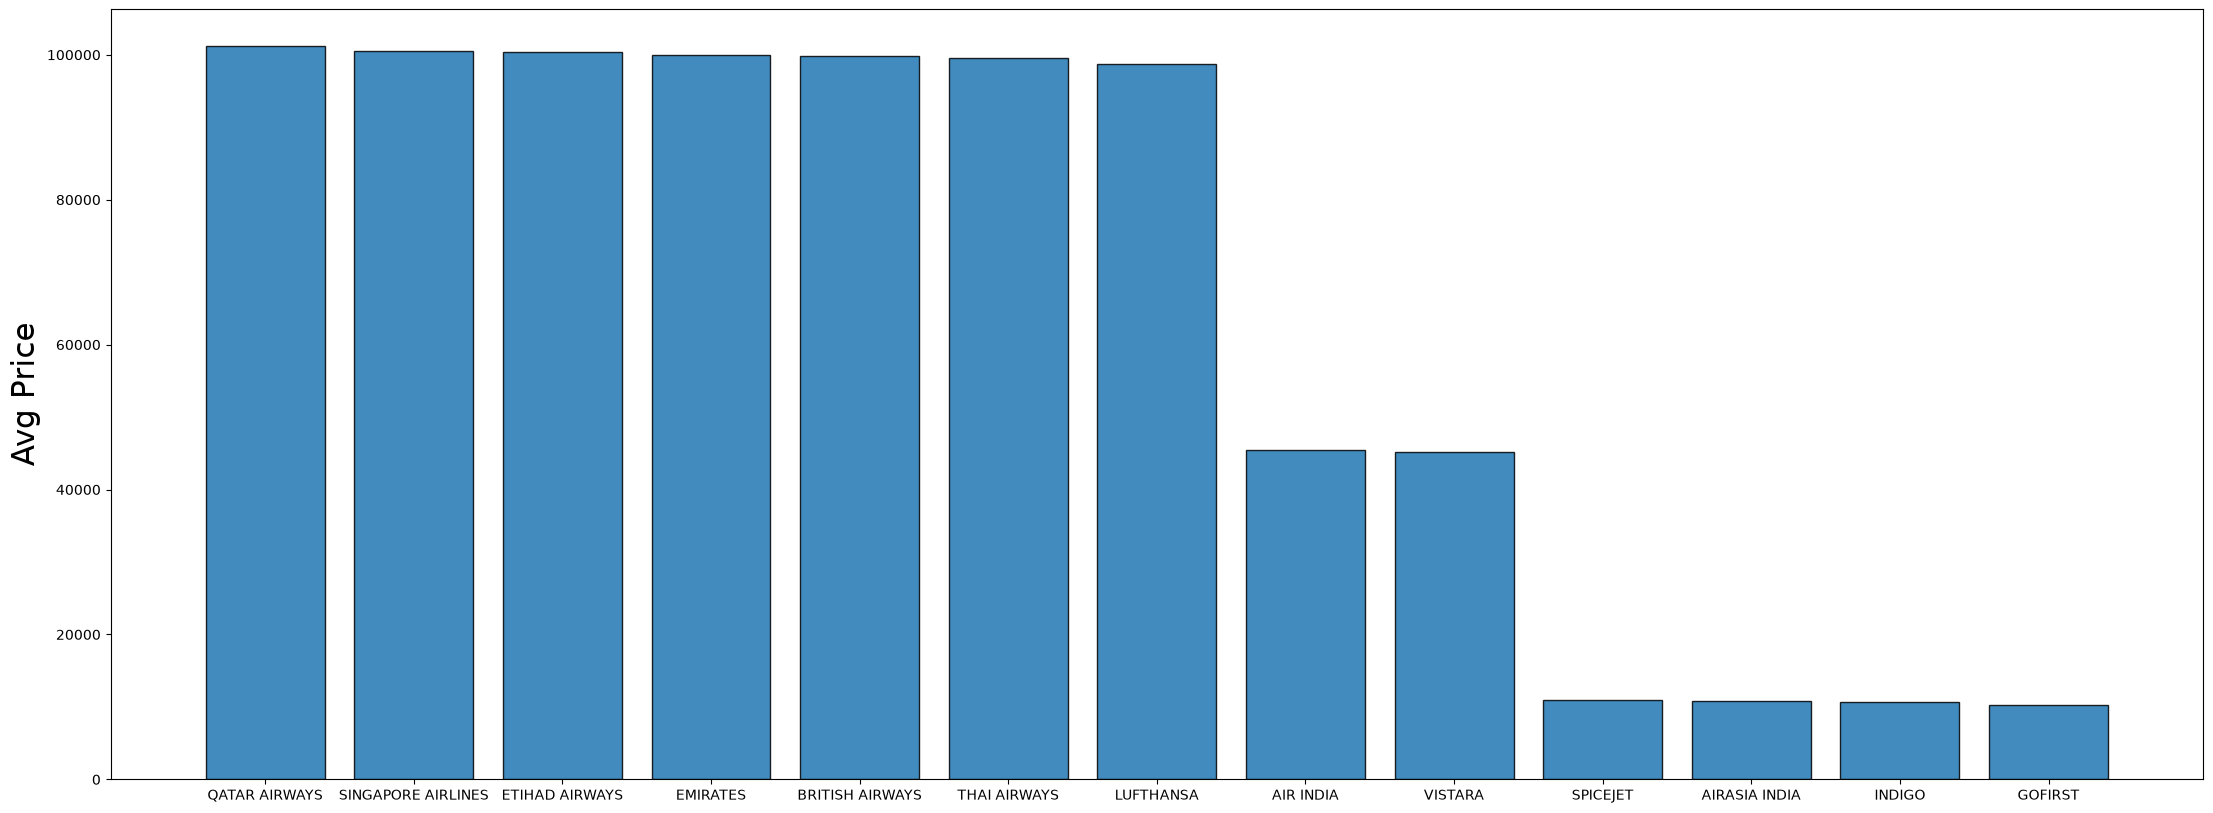

In [6]:
# strings are case sensitive. it creates some problems for example, it treats AIR INDIA and AIR India different.fixing that
df_clean['Airline'] = df_clean['Airline'].astype(str).str.upper()
airlineprice = df_clean.dropna(subset=['Airline','Price']).groupby('Airline')['Price'].mean().reset_index().sort_values(by='Price', ascending=False)
# plotting bar chart of avg price each airline
plt.figure(figsize=(27,10))
plt.bar(airlineprice['Airline'],airlineprice['Price'], alpha=0.85, edgecolor='black',)
plt.ylabel('Avg Price', fontsize=22)
plt.show()

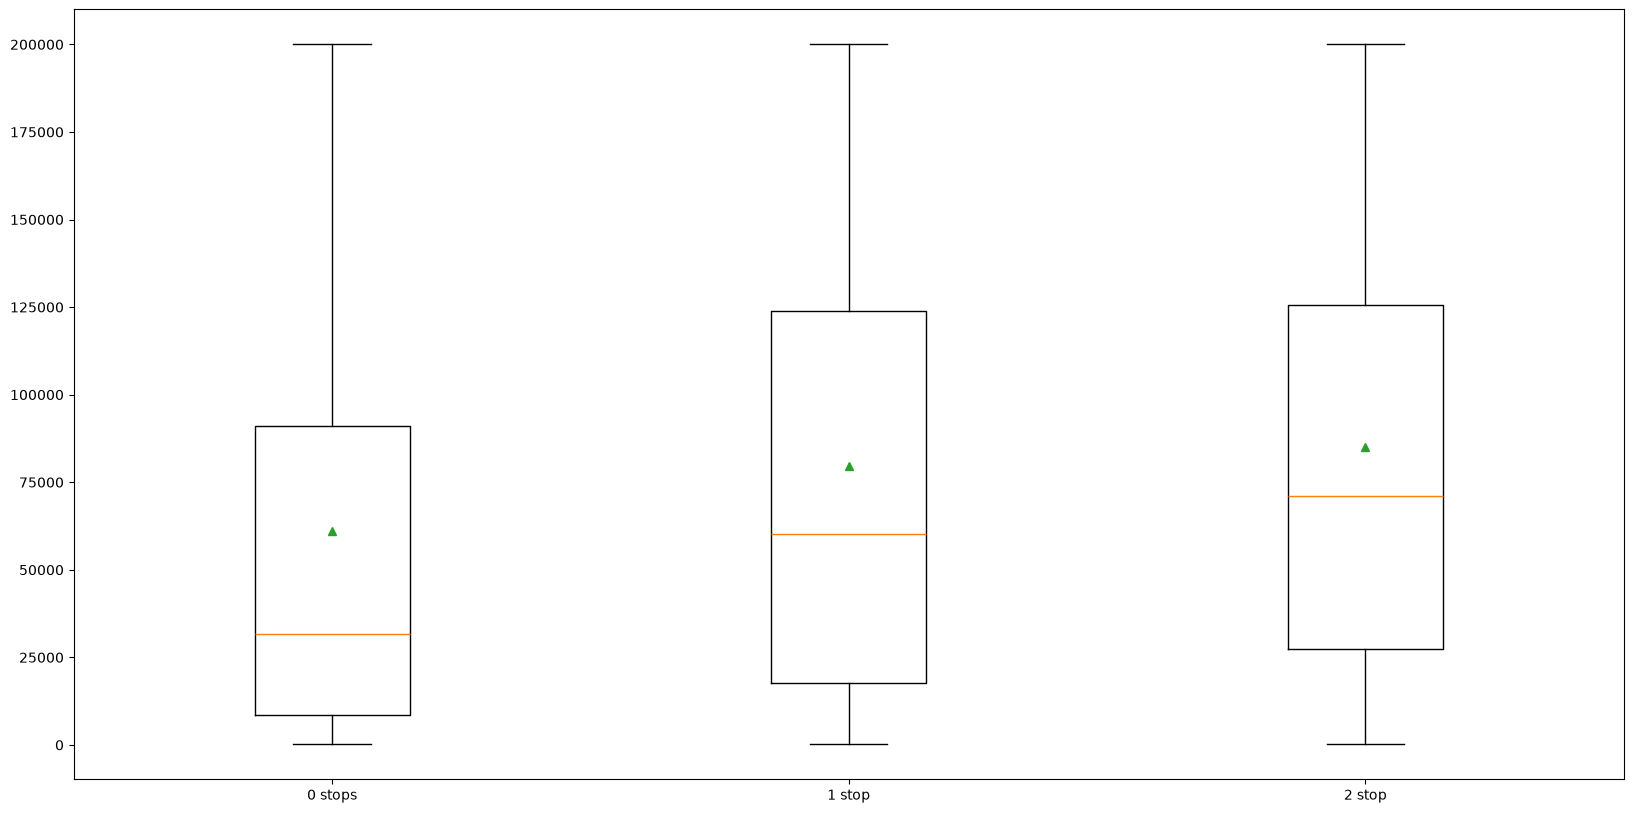

In [7]:
# cleaning Total_Stops
df_clean['Total_Stops'] = df_clean['Total_Stops'].astype(str).str.replace('stop','',regex=False).str.replace('non-stop','0',regex=False)
df_clean['Total_Stops'] = pd.to_numeric(df_clean['Total_Stops'], errors='coerce')
pricestop = df_clean.dropna(subset=['Total_Stops','Price'])
pricestop0 = pricestop[pricestop['Total_Stops'] == 0]
pricestop1 = pricestop[pricestop['Total_Stops'] == 1]
pricestop2 = pricestop[pricestop['Total_Stops'] == 2]
#plotting box plot of price for each of 0,1,2 stop journeys
plt.figure(figsize=(20,10))
plt.boxplot([pricestop0['Price'],pricestop1['Price'],pricestop2['Price']],tick_labels=['0 stops','1 stop', '2 stop'] , showmeans=True, showfliers=False)
plt.show()


1) median and mean price increases with number of stops
2) the cieling of price, which is 2 lakh, is common for all 
3) mean is always higher than median, and as the number of stops increase, median and mean gets closer

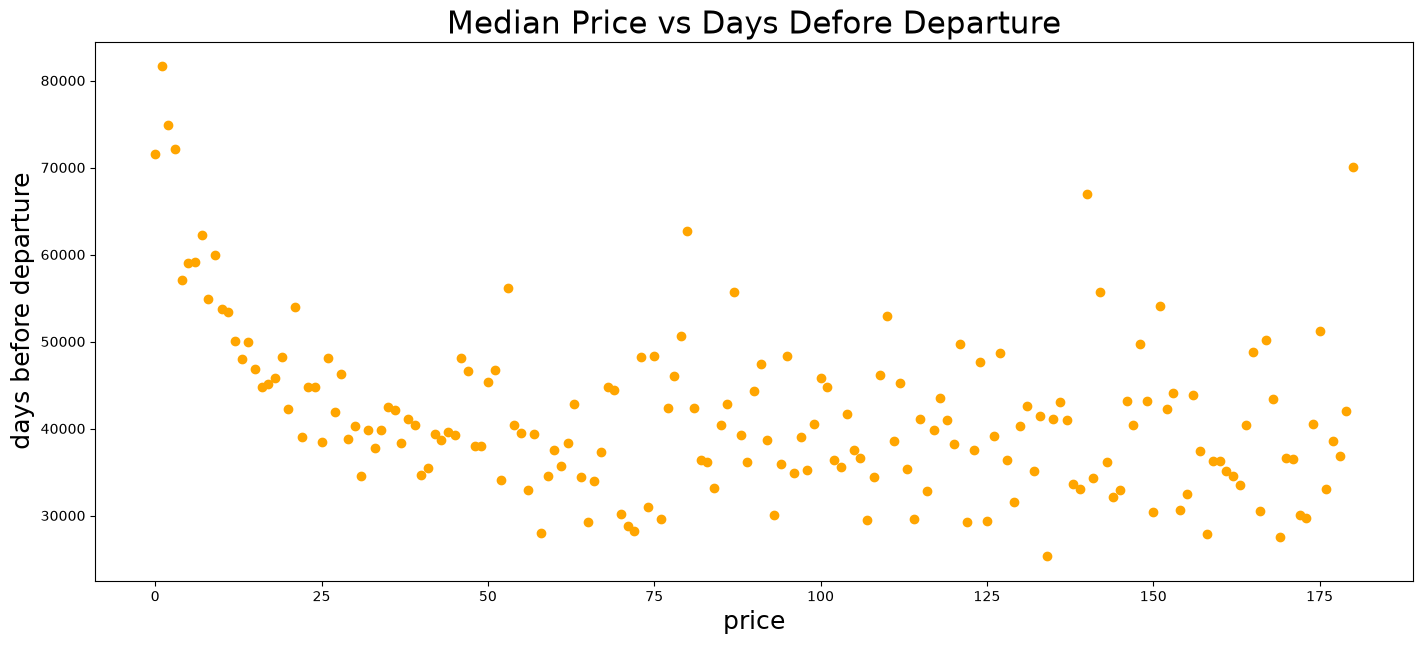

In [8]:
# dropping 'days' from 'Days_Before_Departure' and making it numeric
dbdprice = df_clean.dropna(subset=['Days_Before_Departure','Price'])
dbdprice['Days_Before_Departure'] = dbdprice['Days_Before_Departure'].astype(str).str.replace('days','',regex=False)
dbdprice['Days_Before_Departure'] = pd.to_numeric(dbdprice['Days_Before_Departure'], errors='coerce')
dbdprice_ = dbdprice.groupby('Days_Before_Departure')['Price'].median().reset_index()
# plotting line plot of days before departure and price 
plt.figure(figsize=(17,7))
plt.scatter(dbdprice_['Days_Before_Departure'],dbdprice_['Price'], color='orange')
plt.title('Median Price vs Days Defore Departure', fontsize=22)
plt.xlabel('price', fontsize=18)
plt.ylabel('days before departure', fontsize=18)
plt.show()